In [1]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

In [4]:
df=pd.read_csv("billionaires_2022.csv")

In [8]:
df['net_worth']=df['net_worth'].str.replace(' B','',regex=False)

In [10]:
df['net_worth']=pd.to_numeric(df['net_worth'],errors='coerce')
df=df.dropna(subset=['net_worth'])

In [11]:
df['networth_zscore']=zscore(df['net_worth'])
df['networth_percentile']=df['net_worth'].rank(pct=True)*100

networth_mean=df['net_worth'].mean()
networth_std=df['net_worth'].std()
print(f"Mean of networth: {networth_mean:.2f} B")
print(f"Standard deviation of networth: {networth_std:.2f} B")
print(df.head())
print(df.tail())

Mean of networth: 4.76 B
Standard deviation of networth: 10.54 B
   year  month  rank  net_worth last_name first_name  \
0  2022      4     1      219.0      Musk       Elon   
1  2022      4     2      171.0     Bezos       Jeff   
2  2022      4     3      158.0   Arnault    Bernard   
3  2022      4     4      129.0     Gates       Bill   
4  2022      4     5      118.0   Buffett     Warren   

                  full_name  birth_date   age gender  ...  \
0                 Elon Musk  1971-06-28  50.0   Male  ...   
1                Jeff Bezos  1964-01-12  58.0   Male  ...   
2  Bernard Arnault & family  1949-03-05  73.0   Male  ...   
3                Bill Gates  1955-10-28  66.0   Male  ...   
4            Warren Buffett  1930-08-30  91.0   Male  ...   

  country_of_residence city_of_residence      business_category  \
0        United States            Austin             Automotive   
1        United States           Seattle             Technology   
2               France        

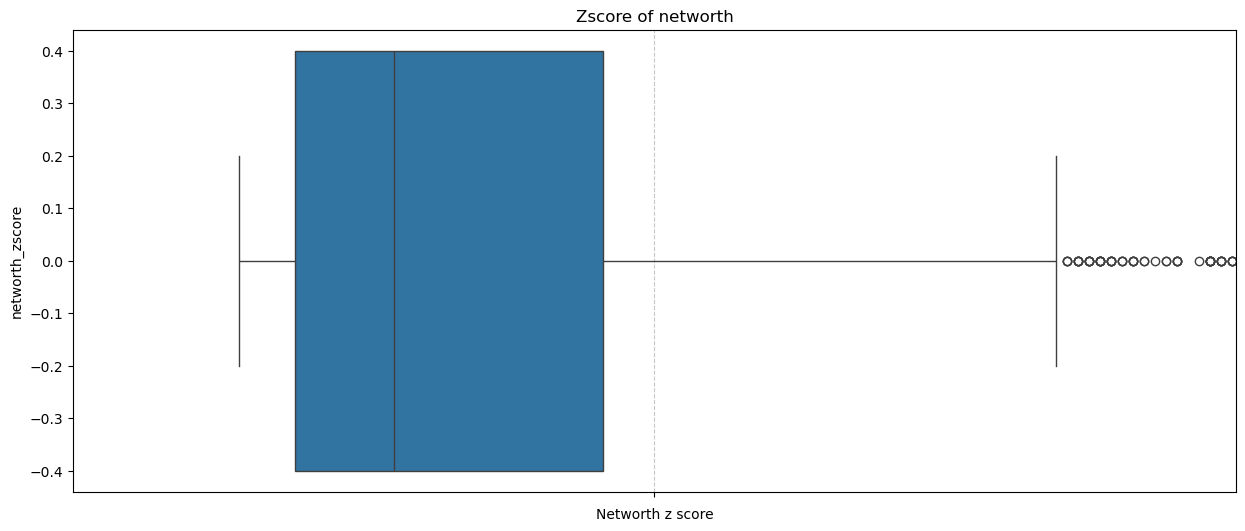

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,6))
sns.boxplot(df['networth_zscore'],vert=False)
plt.title("Zscore of networth")
plt.xlabel("Networth z score")
plt.grid(axis='x',linestyle='--',alpha=0.7)
plt.show()